<a href="https://colab.research.google.com/github/RaisingEntropy/evolutionary_computation/blob/master/coevolution/coevolution_competitive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Competitive Coevolution: Predator vs Prey

In this notebook, we will implement a simple competitive coevolution system.

We will evolve two populations:
- Predators (try to catch prey)
- Prey (try to avoid predators)

Key idea:
Fitness depends on interactions between individuals, not an absolute objective.

## Key Concepts

- Each individual’s fitness depends on its opponents
- Populations evolve simultaneously
- This creates a moving fitness landscape
- Often leads to:
  - Arms races
  - Cycling behavior
  - Red Queen dynamics

We will simulate this in a simplified 1D environment.

In [22]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(0)
random.seed(0)

## Simplified Environment

We represent each individual as a single real number.

Interpretation:
- Predator and prey positions on a 1D line
- Distance between them determines interaction

Fitness:
- Predator: wants to minimize distance
- Prey: wants to maximize distance

In [23]:
# population initialization
pop_size = 30
generations = 50

def init_population():
    return np.random.uniform(-1, 1, pop_size)

predators = init_population()
prey = init_population()

## Fitness Function

We compute fitness based on pairwise interactions:

- Predator fitness increases when it is close to prey
- Prey fitness increases when it is far from predators

We approximate this by sampling interactions between individuals.

In [24]:
# evaluation function
def evaluate(predators, prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        for q in prey:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        for p in predators:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

## Evolution Operators

We use:
- Selection: keep the best half of each population
- Mutation: add Gaussian noise

No crossover is used here for simplicity.

In [25]:
# selection and mutation
def select_parents(pop, fitness, num_parents):
    idx = np.argsort(fitness)[-num_parents:]
    return pop[idx]

def reproduce(parents, pop_size, mutation_std=0.05):
    children = []
    while len(children) < pop_size:
        parent = random.choice(parents)
        child = parent + np.random.normal(0, mutation_std)
        children.append(child)
    return np.array(children)

## Evolution Loop

Both populations evolve simultaneously:
1. Evaluate fitness
2. Select the best individuals
3. Apply mutation
4. Repeat

Observe how each population influences the other over time.

In [26]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate(predators, prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-20.966, Prey fitness=20.966
Gen 1: Pred fitness=-18.935, Prey fitness=18.935
Gen 2: Pred fitness=-19.764, Prey fitness=19.764
Gen 3: Pred fitness=-39.345, Prey fitness=39.345
Gen 4: Pred fitness=-47.199, Prey fitness=47.199
Gen 5: Pred fitness=-48.493, Prey fitness=48.493
Gen 6: Pred fitness=-48.964, Prey fitness=48.964
Gen 7: Pred fitness=-48.232, Prey fitness=48.232
Gen 8: Pred fitness=-47.875, Prey fitness=47.875
Gen 9: Pred fitness=-46.237, Prey fitness=46.237
Gen 10: Pred fitness=-46.083, Prey fitness=46.083
Gen 11: Pred fitness=-46.638, Prey fitness=46.638
Gen 12: Pred fitness=-46.672, Prey fitness=46.672
Gen 13: Pred fitness=-47.816, Prey fitness=47.816
Gen 14: Pred fitness=-47.715, Prey fitness=47.715
Gen 15: Pred fitness=-48.344, Prey fitness=48.344
Gen 16: Pred fitness=-47.551, Prey fitness=47.551
Gen 17: Pred fitness=-46.756, Prey fitness=46.756
Gen 18: Pred fitness=-46.471, Prey fitness=46.471
Gen 19: Pred fitness=-46.079, Prey fitness=46.079
Gen 20: Pr

## Observing the Dynamics

We now visualize how populations evolve over generations.

This helps us see:
- Movement of populations
- Clustering
- Possible oscillations

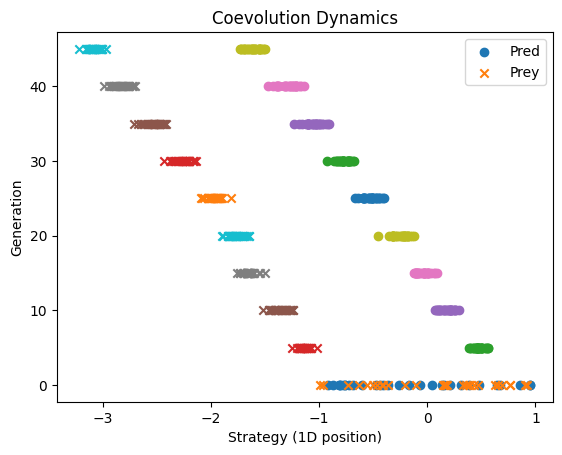

In [27]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 1 - Tournament Sampling
Modify the fitness evaluation so that each individual competes against a random subset of the opposite population instead of the full population.

Specifically:
- For each predator, sample k prey
- For each prey, sample k predators

Compare results with the original full evaluation.

Solutions here: https://github.com/giorgia-nadizar/evolution/blob/master/coevolution/solutions.py

In [28]:
# evaluation function
def evaluate_tournament(predators, prey, k = 10):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        prey_sample = np.random.choice(prey, k)
        for q in prey_sample:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        predator_sample = np.random.choice(predators, k)
        for p in predator_sample:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

In [29]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate_tournament(predators, prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-6.452, Prey fitness=6.238
Gen 1: Pred fitness=-6.178, Prey fitness=6.045
Gen 2: Pred fitness=-10.412, Prey fitness=10.398
Gen 3: Pred fitness=-12.236, Prey fitness=12.426
Gen 4: Pred fitness=-11.759, Prey fitness=11.668
Gen 5: Pred fitness=-11.277, Prey fitness=11.178
Gen 6: Pred fitness=-11.161, Prey fitness=11.216
Gen 7: Pred fitness=-11.293, Prey fitness=11.258
Gen 8: Pred fitness=-11.134, Prey fitness=11.050
Gen 9: Pred fitness=-11.196, Prey fitness=11.209
Gen 10: Pred fitness=-10.978, Prey fitness=10.993
Gen 11: Pred fitness=-11.262, Prey fitness=11.119
Gen 12: Pred fitness=-11.321, Prey fitness=11.332
Gen 13: Pred fitness=-11.285, Prey fitness=11.258
Gen 14: Pred fitness=-11.285, Prey fitness=11.240
Gen 15: Pred fitness=-11.275, Prey fitness=11.243
Gen 16: Pred fitness=-11.218, Prey fitness=11.210
Gen 17: Pred fitness=-11.257, Prey fitness=11.339
Gen 18: Pred fitness=-11.403, Prey fitness=11.396
Gen 19: Pred fitness=-11.581, Prey fitness=11.489
Gen 20: Pred f

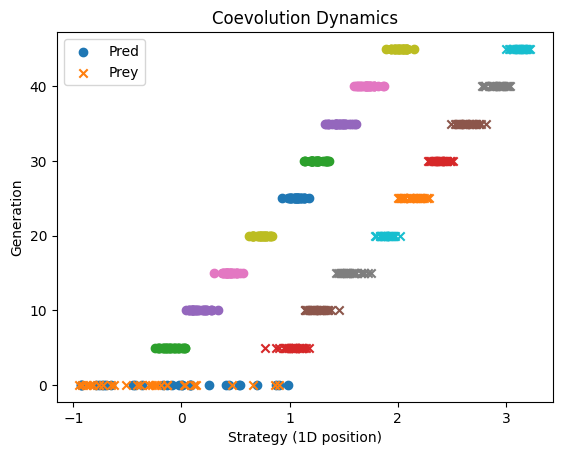

In [30]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 2 - Add a Hall of Fame
Maintain a Hall of Fame: store the best individuals from past generations.

When evaluating fitness:
- Include competition against Hall of Fame individuals

Solutions here: https://github.com/giorgia-nadizar/evolution/blob/master/coevolution/solutions.py

In [43]:
hall_of_fame_pred = []
hall_of_fame_prey = []

def update_hof(pop, fitness, hof, top_k=3):
    idx = np.argsort(fitness)[-top_k:]
    hof.extend(pop[idx])
    return hof

def evaluate_with_hof(predators, prey, hof_pred, hof_prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        opponents = list(prey) + hof_prey
        for q in opponents:
            distance = abs(p - q)
            predator_fitness[i] += -distance  # minimize distance

    for j, q in enumerate(prey):
        opponents = list(predators) + hof_pred
        for p in opponents:
            distance = abs(p - q)
            prey_fitness[j] += distance  # maximize distance

    return predator_fitness, prey_fitness

In [44]:
predators = init_population()
prey = init_population()

history_pred = []
history_prey = []

for gen in range(generations):
    pred_fit, prey_fit = evaluate_with_hof(predators, prey, hall_of_fame_pred, hall_of_fame_prey)

    history_pred.append(predators.copy())
    history_prey.append(prey.copy())

    # Selection (keep top half as parents)
    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    # Reproduction back to full population
    predators = reproduce(pred_parents, pop_size)
    prey = reproduce(prey_parents, pop_size)

    print(f"Gen {gen}: "
          f"Pred fitness={pred_fit.mean():.3f}, "
          f"Prey fitness={prey_fit.mean():.3f}")

Gen 0: Pred fitness=-18.542, Prey fitness=18.542
Gen 1: Pred fitness=-21.458, Prey fitness=21.458
Gen 2: Pred fitness=-28.873, Prey fitness=28.873
Gen 3: Pred fitness=-35.024, Prey fitness=35.024
Gen 4: Pred fitness=-37.389, Prey fitness=37.389
Gen 5: Pred fitness=-38.599, Prey fitness=38.599
Gen 6: Pred fitness=-38.117, Prey fitness=38.117
Gen 7: Pred fitness=-38.211, Prey fitness=38.211
Gen 8: Pred fitness=-38.079, Prey fitness=38.079
Gen 9: Pred fitness=-38.171, Prey fitness=38.171
Gen 10: Pred fitness=-39.230, Prey fitness=39.230
Gen 11: Pred fitness=-39.165, Prey fitness=39.165
Gen 12: Pred fitness=-39.812, Prey fitness=39.812
Gen 13: Pred fitness=-39.929, Prey fitness=39.929
Gen 14: Pred fitness=-40.138, Prey fitness=40.138
Gen 15: Pred fitness=-40.339, Prey fitness=40.339
Gen 16: Pred fitness=-40.846, Prey fitness=40.846
Gen 17: Pred fitness=-41.078, Prey fitness=41.078
Gen 18: Pred fitness=-41.547, Prey fitness=41.547
Gen 19: Pred fitness=-40.738, Prey fitness=40.738
Gen 20: Pr

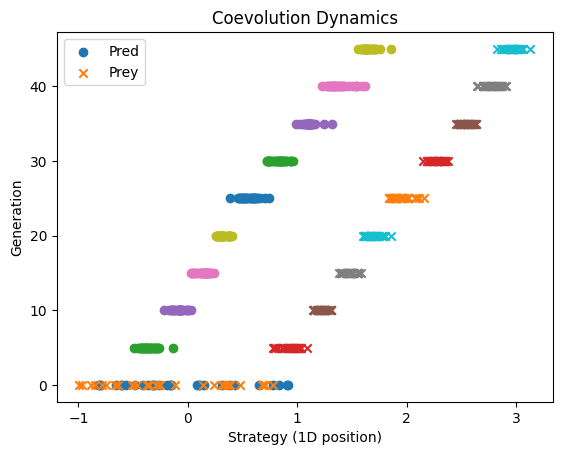

In [45]:
plt.figure()

# for gen in range(0, 10, 1):
for gen in range(0, generations, 5):
    plt.scatter(history_pred[gen], [gen]*len(history_pred[gen]), label="Pred" if gen == 0 else "")
    plt.scatter(history_prey[gen], [gen]*len(history_prey[gen]), marker='x', label="Prey" if gen == 0 else "")

plt.xlabel("Strategy (1D position)")
plt.ylabel("Generation")
plt.title("Coevolution Dynamics")
plt.legend()
plt.show()

## Exercise 3: Extend Coevolution to 2D

So far, individuals were represented as 1D values.

In this exercise:
- Extend individuals to 2D positions: (x, y)
- Predators and prey move in a 2D space
- Fitness is based on Euclidean distance

Questions:
- How does spatial representation affect behavior?
- Do we observe clustering or separation?
- Does coevolution behave differently in 2D?

In [46]:
def init_population_2d():
    return np.random.uniform(-1, 1, (pop_size, 2))

predators = init_population_2d()
prey = init_population_2d()

In [47]:
def evaluate_2d(predators, prey):
    predator_fitness = np.zeros(len(predators))
    prey_fitness = np.zeros(len(prey))

    for i, p in enumerate(predators):
        for q in prey:
            distance = np.linalg.norm(p - q)
            predator_fitness[i] += -distance

    for j, q in enumerate(prey):
        for p in predators:
            distance = np.linalg.norm(p - q)
            prey_fitness[j] += distance

    return predator_fitness, prey_fitness

In [48]:
def reproduce_2d(parents, pop_size, mutation_std=0.05):
    children = []
    while len(children) < pop_size:
        parent = random.choice(parents)
        child = parent + np.random.normal(0, mutation_std, size=2)
        children.append(child)
    return np.array(children)

In [55]:
pred_history = []
prey_history = []

predators = init_population_2d()
prey = init_population_2d()

for gen in range(generations):
    pred_fit, prey_fit = evaluate_2d(predators, prey)

    pred_history.append((predators.copy(), gen))
    prey_history.append((prey.copy(), gen))

    pred_parents = select_parents(predators, pred_fit, pop_size // 2)
    prey_parents = select_parents(prey, prey_fit, pop_size // 2)

    predators = reproduce_2d(pred_parents, pop_size)
    prey = reproduce_2d(prey_parents, pop_size)

## Visualization with Temporal Color Encoding

Instead of plotting generations on the y-axis, we now:

- Use position (x, y) as the axes
- Encode generation using a color gradient

This allows us to see:
- How populations move over time
- Whether they converge or drift
- How strategies evolve temporally in space

In [56]:
def flatten_history(history):
    xs, ys, gens = [], [], []
    for positions, gen in history:
        for p in positions:
            xs.append(p[0])
            ys.append(p[1])
            gens.append(gen)
    return np.array(xs), np.array(ys), np.array(gens)

pred_x, pred_y, pred_g = flatten_history(pred_history)
prey_x, prey_y, prey_g = flatten_history(prey_history)

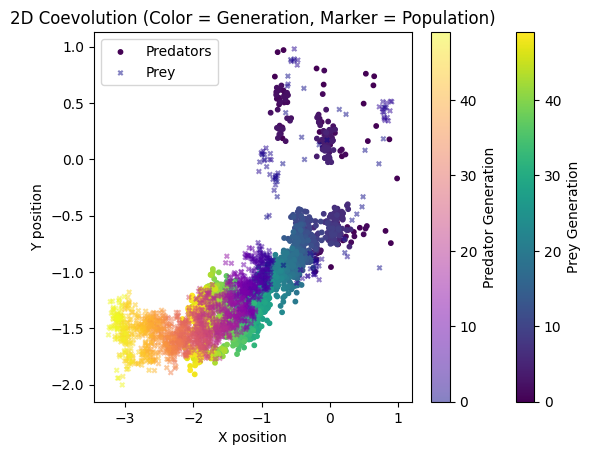

In [57]:
plt.figure()

# Predators: circle markers
plt.scatter(
    pred_x, pred_y,
    c=pred_g,
    cmap='viridis',
    s=10,
    marker='o',
    label="Predators",
)
plt.colorbar(label="Prey Generation")

# Prey: cross markers
plt.scatter(
    prey_x, prey_y,
    c=prey_g,
    cmap='plasma',
    s=10,
    marker='x',
    label="Prey",
    alpha=.5,
)
plt.colorbar(label="Predator Generation")

plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("2D Coevolution (Color = Generation, Marker = Population)")
plt.legend()
plt.show()